In [1]:
from pathlib import Path
import glob
import warnings

from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd

from thomas2024.calibration import assemble_thresholds, lookup_pop_at_risk


display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))
pd.set_option('display.max_rows', 50)

In [2]:
storm_set_params = {
    "STORM_constant": ("STORM", 2000, None, None),
    "STORM_CNRM-CM6-1-HR": ("STORM", 2050, "RCP8.5", "CNRM"),
    "STORM_CMCC-CM2-VHR4": ("STORM", 2050, "RCP8.5", "CMCC"),
    "STORM_EC-Earth3P-HR": ("STORM", 2050, "RCP8.5", "EC-Earth"),
    "STORM_HadGEM3-GC31-HM": ("STORM", 2050, "RCP8.5", "HadGEM3"),

    "IRIS_PRESENT": ("IRIS", 2000, None, None),
    "IRIS_SSP5-2050": ("IRIS", 2050, "SSP5-8.5", None),

    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2010": ("CHAZ", 2010, None, "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2010": ("CHAZ", 2010, None, "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2010": ("CHAZ", 2010, None, "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2010": ("CHAZ", 2010, None, "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2010": ("CHAZ", 2010, None, "MIROC6"),
    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "MIROC6"),

    "emanuel_ssp-585_gcm-cesm2_epoch-2005": ("Emanuel", 2005, None, "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2005": ("Emanuel", 2005, None, "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2005": ("Emanuel", 2005, None, "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2005": ("Emanuel", 2005, None, "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2005": ("Emanuel", 2005, None, "UKMO6"),
    "emanuel_ssp-585_gcm-cesm2_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "UKMO6"),
}

group_colours = {
    "IRIS": "lightgreen",
    "STORM": "plum",
    "CHAZ": "pink",
    "MIT": "lightblue",
}

sample_countries = (
    "NIC",
    "GTM",
    "USA",
    "DOM",
    "CUB",
    "MEX",
    "LKA",
    "MDG",
    "MOZ",
    "MMR",
    "BGD",
    "IND",
    "TWN",
    "KOR",
    "VNM",
    "PHL",
    "JPN",
    "CHN",
)

In [3]:
# Input data paths
country_thresholds_path = Path("data/20260907_country_thresholds.csv")
income_thresholds_path = Path("data/20260907_income_thresholds.csv")
wb_income_path = Path("data/OGHIST_2026_07_15.xlsx")
results_dir = Path("/data/tc-grid/open-gira/results")

# Output paths
plot_dir = Path("../plots")

thresholds_by_country = assemble_thresholds(wb_income_path, income_thresholds_path, country_thresholds_path)

metrics = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/metrics.pq"))))])
metrics = metrics.dropna(how="all")
metrics["gamma_index"] = metrics["gamma_index"].astype(float)
metrics = metrics.rename(columns={c: f"net_{c}" for c in metrics.columns})

nodes = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/nodes.geoparquet"))))])
node_pop = nodes.loc[:, ["iso_a3", "population"]].dropna().groupby("iso_a3").sum().rename(columns={"population": "total_pop"})

risk = []
for atmosphere, (model, epoch, scenario, gcm) in storm_set_params.items():
    df = pd.read_parquet(results_dir / f"power/by_storm_set/{atmosphere}/disruption/drivers.pq")
    df["model"] = model
    df["epoch"] = epoch
    df["scenario"] = scenario
    df["gcm"] = gcm
    risk.append(lookup_pop_at_risk(df, thresholds_by_country))

df = pd.concat(risk)
df = df.merge(metrics.reset_index(), on="iso_a3")
df = df.merge(node_pop.reset_index(), on="iso_a3")
df["wind_exceedance_ms-1"] = df["max_wind_speed_ms"] - df["threshold_ms-1"]
df["pop_at_risk_ratio"] = df["pop_at_risk"] / df["total_pop"]
df = df[df["pop_at_risk_ratio"] > 0]


In [4]:
"""
Per-country ramp-then-plateau ("hinge") quantile fit of outage risk on wind exceedance.

Workflow:
    raw events -> equal-count exceedance bins -> q95 per bin -> hinge fit

Also plots the binned q95 points and fitted hinge over the original hexbin panels.

Expects `df` and `valid_iso_a3` to exist in the calling namespace.
"""


EXC, RISK = "wind_exceedance_ms-1", "pop_at_risk_ratio"
Q_UPPER, Q_MEDIAN = 0.95, 0.50
N_EXC_BINS, MIN_BIN_EVENTS = 10, 30
N_B_GRID, B_MAX_MULT = 40, 1.2
MIN_EVENTS, N_BOOT, SEED = 30, 50, 42
INCOME_LEVELS = ("H", "UM", "LM", "L")


def _weighted_quantile(values, weights, q):
    values, weights = np.asarray(values, float), np.asarray(weights, float)
    ok = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values, weights = values[ok], weights[ok]
    if not len(values):
        raise ValueError("No valid values for weighted quantile.")
    order = np.argsort(values); values, weights = values[order], weights[order]
    cw = np.cumsum(weights) - 0.5 * weights; cw /= weights.sum()
    return float(np.interp(q, cw, values))


def _pinball(resid, q):
    return np.sum(np.where(resid >= 0, q * resid, (q - 1) * resid))


def bin_exceedance_quantiles(g, n_bins=N_EXC_BINS, min_bin_events=MIN_BIN_EVENTS, q=Q_UPPER):
    """Equal-count exceedance bins; return median x, within-bin q-risk, n, and bin range."""
    g = g[[EXC, RISK]].dropna()
    g = g[g[EXC] > 0].sort_values(EXC).reset_index(drop=True)
    empty = pd.DataFrame(columns=["x", "y", "n", "x_min", "x_max"])
    if len(g) < min_bin_events:
        return empty
    n_bins = min(int(n_bins), len(g) // min_bin_events)
    if n_bins < 1:
        return empty
    rows = []
    for idx in np.array_split(np.arange(len(g)), n_bins):
        b = g.iloc[idx]
        if len(b) >= min_bin_events:
            rows.append({"x": b[EXC].median(), "y": b[RISK].quantile(q), "n": len(b),
                         "x_min": b[EXC].min(), "x_max": b[EXC].max()})
    return pd.DataFrame(rows)


def fit_hinge(x, y, q, n_b_grid=N_B_GRID, b_max_mult=B_MAX_MULT):
    """Fit y_hat = s * min(x, b) at quantile q."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x, y = x[ok], y[ok]
    if len(x) < 2:
        raise ValueError("Need at least two valid points for hinge fit.")
    lo, hi = max(2.0, x.max() * 0.02), x.max() * b_max_mult
    if hi <= lo:
        hi = lo * 1.01
    best_loss, best = np.inf, None
    for b in np.linspace(lo, hi, n_b_grid):
        m = np.minimum(x, b)
        s = _weighted_quantile(y / m, m, q)
        loss = _pinball(y - s * m, q)
        if loss < best_loss:
            best_loss, best = loss, (s, b)
    if best is None:
        raise ValueError("Could not find a valid hinge fit.")
    s, b = best
    return {"slope": float(s), "breakpoint": float(b), "plateau": float(np.clip(s * b, 0, 1))}


def curve_at(x_vals, fit):
    x_vals = np.asarray(x_vals, float)
    return fit["slope"] * np.minimum(x_vals, fit["breakpoint"])


def fit_country(g, rng, n_boot=N_BOOT):
    g = g[[EXC, RISK]].dropna()
    g = g[g[EXC] > 0]
    if len(g) < MIN_EVENTS:
        return None

    upper = bin_exceedance_quantiles(g, q=Q_UPPER)
    median = bin_exceedance_quantiles(g, q=Q_MEDIAN)
    if len(upper) < 2:
        return None

    edge = fit_hinge(upper["x"], upper["y"], Q_UPPER)
    med = fit_hinge(median["x"], median["y"], Q_MEDIAN) if len(median) >= 2 else {"plateau": np.nan}
    x, y = g[EXC].to_numpy(), g[RISK].to_numpy()

    out = {
        "sensitivity": edge["slope"] * 10,
        "breakpoint": edge["breakpoint"],
        "baseline": edge["plateau"],
        "baseline_median": med["plateau"],
        "n_events": len(g),
        "frac_nonzero": float((y > 0).mean()),
        "n_bins_used": int(len(upper)),
        "max_binned_exceedance": float(upper["x"].max()),
        "saturates_in_range": bool(edge["breakpoint"] < upper["x"].max() * (B_MAX_MULT - 0.05)),
    }

    boots = []
    for _ in range(n_boot):
        try:
            gb = g.iloc[rng.integers(0, len(g), len(g))]
            bb = bin_exceedance_quantiles(gb, q=Q_UPPER)
            if len(bb) < 2:
                continue
            f = fit_hinge(bb["x"], bb["y"], Q_UPPER)
            boots.append({"sensitivity": f["slope"] * 10, "baseline": f["plateau"]})
        except Exception:
            continue

    b = pd.DataFrame(boots)
    for k in ("sensitivity", "baseline"):
        out[f"{k}_lo"], out[f"{k}_hi"] = (np.percentile(b[k], [5, 95]) if len(b) else (np.nan, np.nan))

    return out, upper, median


def fit_all(df, valid_iso_a3, seed=SEED):
    rng = np.random.default_rng(seed)
    d = df[df["iso_a3"].isin(valid_iso_a3)]
    rows, fits, binned_points = {}, {}, {}

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for iso, g in d.groupby("iso_a3"):
            result = fit_country(g, rng)
            if result is None:
                continue
            r, upper, median = result
            r["income_level"] = g["income_level"].mode().iat[0]
            rows[iso] = r
            fits[iso] = fit_hinge(upper["x"], upper["y"], Q_UPPER)
            binned_points[iso] = {"upper": upper, "median": median}

    res = pd.DataFrame(rows).T.infer_objects()
    res.index.name = "iso_a3"
    return res, fits, binned_points


def plot_risk_sensitivity(res, ax=None):
    ax = ax or plt.subplots(figsize=(8, 6.5))[1]
    levels = INCOME_LEVELS
    colours = dict(zip(levels, plt.cm.viridis(np.linspace(0.05, 0.9, len(levels)))))

    for iso, r in res.iterrows():
        x, y = r["baseline"], r["sensitivity"]
        xerr = [[max(0, x - r["baseline_lo"])], [max(0, r["baseline_hi"] - x)]]
        yerr = [[max(0, y - r["sensitivity_lo"])], [max(0, r["sensitivity_hi"] - y)]]
        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o", ms=6, color=colours[r["income_level"]], ecolor="0.7", elinewidth=0.8, capsize=0, zorder=3)
        ax.annotate(iso, (x, y), xytext=(4, 4), textcoords="offset points", fontsize=8)

    for lv in levels:
        ax.plot([], [], "o", color=colours[lv], label=lv)
    ax.legend(title="Income level", frameon=False, fontsize=8)
    ax.axhline(0, color="0.8", lw=0.8, zorder=1)
    ax.set_xlabel(f"Baseline risk: q{int(Q_UPPER * 100)} plateau (ceiling risk)")
    ax.set_ylabel(f"Sensitivity: q{int(Q_UPPER * 100)} leading-edge slope per +10 m/s")
    ax.grid(alpha=0.25)
    return ax


def plot_hexbin_with_fits(df, valid_iso_a3, fits, binned_points=None, res=None, MIN_POP=1e6, MIN_OBS=1e3,
                          DROP_COUNTRIES=(), MIN_EXCEEDANCE=-24, MAX_EXCEEDANCE=75, N_BINS=32,
                          vmin=1, vmax=50, n_cols=6, show_median=True):
    """Plot hexbin panels with binned q95 points, hinge fits, and breakpoints."""
    binned_points = binned_points or {}
    iso_a3_by_pop = df.loc[df.iso_a3.isin(valid_iso_a3), ["iso_a3", "total_pop"]].groupby("iso_a3").first().sort_values("total_pop")
    n_rows = (len(iso_a3_by_pop) + n_cols - 1) // n_cols
    f, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), squeeze=False)
    axes = axes.ravel()
    cmap = plt.get_cmap("magma_r"); cmap.set_under("white")
    outline = [pe.withStroke(linewidth=3.5, foreground="white")]
    hb = None

    for i, (iso_a3, ax) in enumerate(zip(iso_a3_by_pop.index, axes)):
        data = df[(df.iso_a3 == iso_a3) & (df[EXC] < MAX_EXCEEDANCE)]
        hb = ax.hexbin(data[EXC], data[RISK], gridsize=(N_BINS, N_BINS), vmin=vmin, vmax=vmax, cmap=cmap,
                       extent=(MIN_EXCEEDANCE, MAX_EXCEEDANCE, 0, 1))
        ax.set_xlim(MIN_EXCEEDANCE, MAX_EXCEEDANCE); ax.set_ylim(0, 1.05)

        ratio = data[RISK].dropna()
        hist_counts, hist_edges = np.histogram(ratio, bins=np.linspace(0, 1.05, 32))
        x0, x1 = ax.get_xlim(); hist_width = 0.25 * (x1 - x0)
        max_count = hist_counts.max() if hist_counts.max() > 0 else 1
        widths = hist_counts / max_count * hist_width
        ax.barh((hist_edges[:-1] + hist_edges[1:]) / 2, widths, height=np.diff(hist_edges),
                left=x0, align="center", alpha=0.35, edgecolor="none", zorder=2)

        if iso_a3 in binned_points:
            bp = binned_points[iso_a3]["upper"]
            if len(bp):
                sizes = 18 + 0.1 * bp["n"]
                ax.scatter(bp["x"], bp["y"], s=sizes, facecolor="white", edgecolor="white", linewidth=2.5, alpha=0.5, zorder=5)
                ax.scatter(bp["x"], bp["y"], s=sizes, facecolor="black", edgecolor="white", linewidth=0.7, alpha=0.5, zorder=6,
                           label=f"binned q{int(Q_UPPER * 100)}")

        if iso_a3 in fits:
            fit = fits[iso_a3]
            ax.plot([0, fit["breakpoint"], MAX_EXCEEDANCE], [0, fit["plateau"], fit["plateau"]],
                    color="dodgerblue", lw=2, zorder=7, path_effects=outline, label=f"q{int(Q_UPPER * 100)} hinge fit")
            ax.axvline(fit["breakpoint"], color="dodgerblue", lw=0.7, ls=":", alpha=0.6, zorder=4)

        if i // n_cols != n_rows - 1:
            ax.set_xticklabels([])
        if i % n_cols != 0:
            ax.set_yticklabels([])
        ax.grid(which="both", alpha=0.2)
        ax.text(0.05, 0.87, iso_a3, transform=ax.transAxes)

    for ax in axes[len(iso_a3_by_pop):]:
        ax.axis("off")

    f.supxlabel("Wind exceedance [ms-1]", y=0.08)
    f.supylabel("Pop. at risk in event / connected pop.", x=0.08)
    if hb is not None:
        f.colorbar(hb, ax=axes.tolist(), location="right", pad=0.02, fraction=0.025, label="Frequency")
    plt.subplots_adjust(bottom=0.14, left=0.12, top=0.95, right=0.85)
    return f, axes

In [5]:
MIN_POP = 1E6
MIN_OBS = 1E3
DROP_COUNTRIES = ["NIC", "GTM", "MOZ", "MDG"]

obs_per_iso_a3 = df.loc[:, ["iso_a3", "pop_at_risk"]].groupby("iso_a3").count().rename(columns={"pop_at_risk": "count"})
valid_iso_a3 = pd.Series(
    list(
        set(obs_per_iso_a3[obs_per_iso_a3["count"] > MIN_OBS].index)
        & set(df[df.total_pop > MIN_POP].iso_a3.unique())
        - set(DROP_COUNTRIES)
    )
)

res, fits, binned_points = fit_all(df, valid_iso_a3)

if not res["saturates_in_range"].all():
    print("\nNo saturation seen within observed binned exceedance range for:",
            list(res.index[~res["saturates_in_range"]]),
            "-- their 'baseline' is extrapolated beyond the binned data.")

res.round(3).sort_values("sensitivity", ascending=False)

,sensitivity,breakpoint,baseline,baseline_median,n_events,frac_nonzero,n_bins_used,max_binned_exceedance,saturates_in_range,sensitivity_lo,sensitivity_hi,baseline_lo,baseline_hi,income_level
iso_a3,,,,,,,,,,,,,,
CUB,0.785,12.303,0.966,0.440,4088,1.0,10,43.523,True,0.707,0.844,0.965,0.971,UM
JAM,0.737,13.197,0.972,0.877,1409,1.0,10,42.100,True,0.726,0.818,0.972,0.979,UM
PRI,0.719,13.900,0.999,0.717,1840,1.0,10,40.341,True,0.676,0.793,0.999,1.000,H
DOM,0.638,15.013,0.958,0.151,2758,1.0,10,40.114,True,0.594,0.849,0.954,0.982,UM
KHM,0.566,15.540,0.880,0.318,1162,1.0,10,45.672,True,0.552,0.803,0.798,0.889,LM
PRK,0.419,19.741,0.827,0.210,4119,1.0,10,33.699,True,0.401,0.455,0.821,0.859,L
TWN,0.386,22.310,0.861,0.284,12400,1.0,10,38.337,True,0.374,0.410,0.844,0.878,H
KOR,0.326,20.906,0.681,0.201,5265,1.0,10,32.389,True,0.305,0.350,0.673,0.716,H
LKA,0.248,28.583,0.708,0.048,1396,1.0,10,40.937,True,0.222,0.337,0.634,0.725,LM


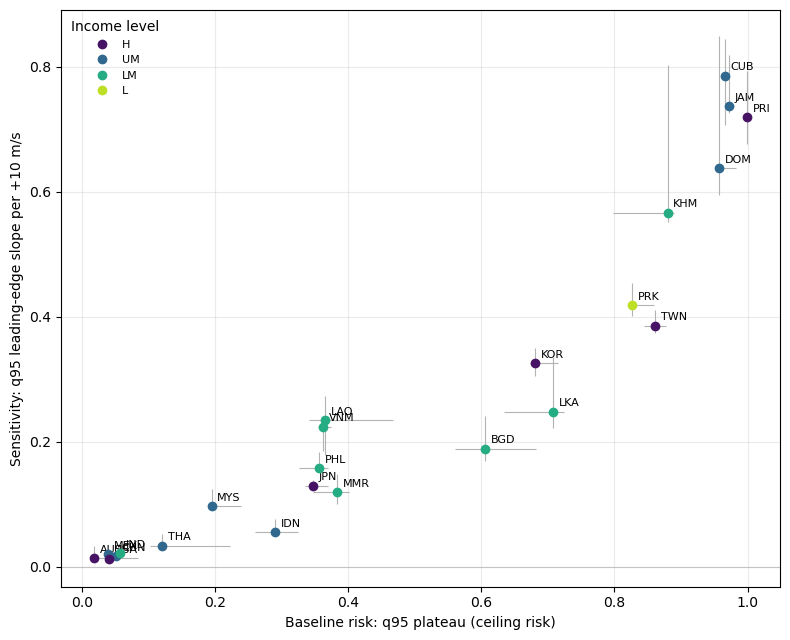

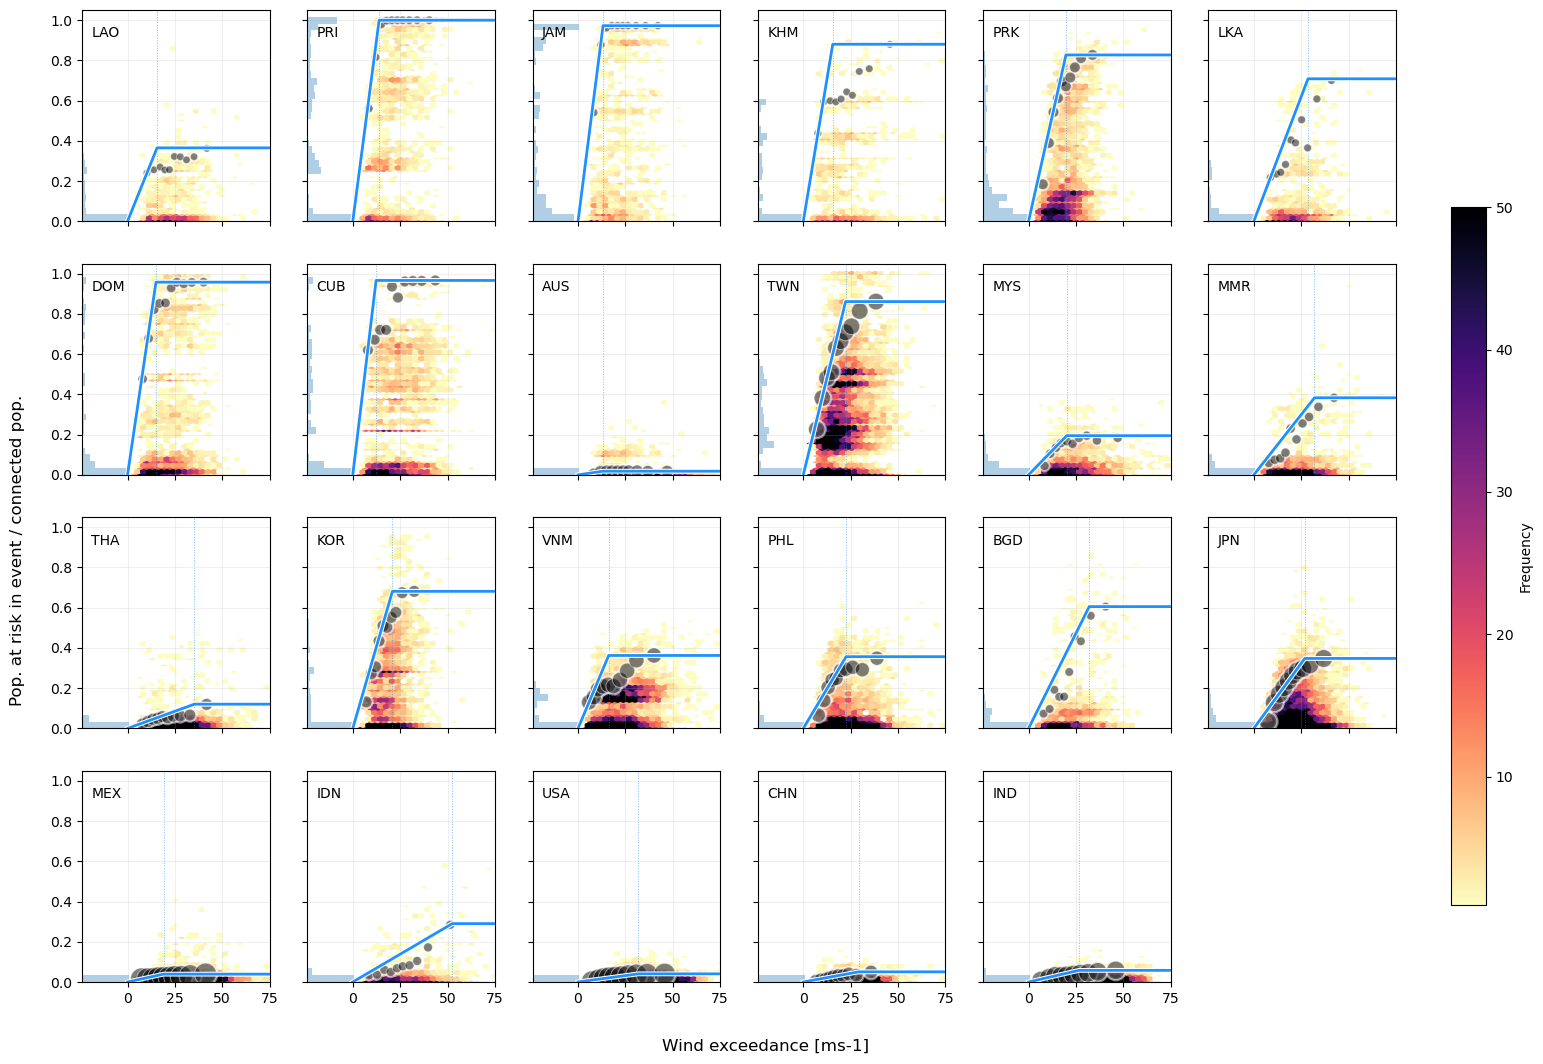

In [6]:
plot_risk_sensitivity(res)
plt.tight_layout()
plt.savefig("risk_vs_sensitivity.png", dpi=200, bbox_inches="tight")

f, axes = plot_hexbin_with_fits(df, valid_iso_a3, fits, binned_points=binned_points, res=res)
f.savefig("pop_at_risk_ratio_vs_exceedance_with_fits.png", bbox_inches="tight", pad_inches=0.4)
plt.show()